# Grid method

## Unit 1 Create FCC grids

In [86]:
!git clone https://github.com/kaifengZheng/shape_proj_util.git

Cloning into 'shape_proj_util'...


In [7]:
from itertools import *
import seaborn as sea
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ase import Atoms
from ase.visualize import view
from random import sample,seed
from shape_proj_util.geo_tools.geometry import *
from ase.io.xyz import write_xyz
from scipy.spatial.distance import cdist
import random

In [8]:
#a: lattice constant
#x,y,z are how many times lattice extends along this direction
#x,y,z must large than 1
def fccbasis(a):
    fcc = [[0,0.5*a,0.5*a],[0.5*a,0,0.5*a],[0.5*a,0.5*a,0],[0,0,0],\
                    [0,0,a],[0,a,0],[a,0,0],[a,a,0],\
                    [0,a,a],[a,0,a],[a,a,a],[a,0.5*a,0.5*a],\
                    [0.5*a,a,0.5*a],[0.5*a,0.5*a,a]]
    return np.array(fcc)

#lattice is an array containing coordinates in fcc
def extendfcc(lattice,a,x,y,z):
    lattice_extend = []
    for i in range(0,x):
        for j in range(0,y):
            for k in range(0,z):
                for o in range(0,len(lattice)):
                    if not lattice_extend.__contains__([lattice[o][0]+i*a,lattice[o][1]+j*a,lattice[o][2]+k*a]):
                        lattice_extend.extend([[lattice[o][0]+i*a,lattice[o][1]+j*a,lattice[o][2]+k*a]])
    return np.array(lattice_extend)

In [9]:
%matplotlib widget

# Generate fcc particles using genetic algorithm or particle swarm optimization

## Step 0: create a sampling space(given bond length: $lattice\ constant=\sqrt{2} r$, number of atoms: $N$)
$$lattice\ space=\sqrt[3]{2N}\times\sqrt[3]{2N}\times\sqrt[3]{2N}$$

In [10]:
lattice=extendfcc(fccbasis(3.6),3.6,4,4,4)
mid_position=np.mean(lattice,axis=0)
lattice_shift=np.round(lattice-mid_position,3)
mid_position=np.round(np.mean(lattice_shift,axis=0),3)
print(f"lattice has {len(lattice_shift)} points.")

lattice has 365 points.


In [11]:
test_coord=8.9
surface_vol=0.7
num_atom=100
bulk_atom=np.ceil(100*0.3)


In [12]:
dist=np.round(cdist([mid_position],lattice_shift),3)
dist_dict=Counter(dist[0])
sorted_count=sorted(dist_dict.items(),key=lambda x:x[0],reverse=False)
local=np.where(dist==sorted_count[1][0])
local2=np.where(dist==sorted_count[2][0])
local3=np.where(dist==sorted_count[3][0])
# local4=np.where(dist==sorted_count[4][0])
all_zeos=np.zeros(len(lattice_shift))
all_zeos[local[1]]=1
all_zeos[local2[1]]=1
all_zeos[local3[1]]=1

len(all_zeos[all_zeos==1])


42

In [13]:
sorted_count[1][0]

2.546

In [14]:
local2

(array([0, 0, 0, 0, 0, 0], dtype=int64),
 array([ 52, 133, 151, 159, 173, 236], dtype=int64))

In [15]:
#lattice making
def empty_lattice(lc,num_atoms):
    min_num_points=num_atoms*2
    num_lattice=min_num_points//2
    multiplicity=int(np.ceil(np.cbrt(num_lattice)))
    print(multiplicity)

    lattice=extendfcc(fccbasis(lc),lc,multiplicity,multiplicity,multiplicity)
    mid_position=np.mean(lattice,axis=0)
    lattice_shift=np.round(lattice-mid_position,6)
    print(f"lattice has {len(lattice_shift)} points.")
    
    return np.array(lattice_shift)


def random_genome(genome_size,num_atoms):
    genome=np.zeros(genome_size)
    index=random.sample(range(0,genome_size),num_atoms)
    genome[index]=1
    return genome


def clustering_energy(genome,lattice):
    index=np.where(np.array(genome)==1)
    position=lattice[index]
    mid_position=np.mean(position,axis=0)
    dist=np.round(cdist([mid_position],position),6)
    dist_ave=np.sum(dist)/len(dist) #this is the clustering energy
    return dist_ave


def ini_population(genome_size,population_size,num_atoms):
    return [random_genome(genome_size,num_atoms) for _ in range(0,population_size)]

def fitness(genome,lattice_shift,discriptors:dict):
    genome=np.array(genome)
    atom=Atoms(positions=lattice_shift[genome==1],symbols=['Pt']*len(lattice_shift[genome==1]))
    cluster_discriptors=descriptor_table(atom)
    true_dis=np.array([discriptors[k] for k in discriptors.keys()])
    # print(true_dis)
    pred_dis=np.array([cluster_discriptors[k] for k in discriptors.keys()])
    # print(pred_dis)
    #MSE
    return np.sum((true_dis-pred_dis)**2)

def parents(population,fitness_values):
    Max_fitness=max(fitness_values)
    # Max_clustering_energy=max(clustering_energy_values)
    threshold=random.uniform(0,Max_fitness)
    # threshold_2=random.uniform(0,Max_clustering_energy)
    current=Max_fitness
    # current_2=Max_clustering_energy
    for i in range(0,len(population)):
        current-=fitness_values[i]
        current
        if current<threshold:
            return list(population[i])
def crossover(parent1,parent2,cross_over_rate=0.5):
    if random.random()<cross_over_rate:
        crossover_point=random.randint(1,len(parent1)-1)
        # print(parent1)
        # print(parent2)
        return parent1[:crossover_point]+parent2[crossover_point:],parent2[:crossover_point]+parent1[crossover_point:]
    else:
        return parent1,parent2

def mutation(genome,lattice,num_atom,mutation_rate=0.1):
    #check atom_num
    # print(genome)
    
 
    particle_index=np.where(np.array(genome)==1)[0]
    lattice_particle=lattice[particle_index]
    # center=np.mean(lattice_particle,axis=0)
    dist=np.round(cdist([[0,0,0]],lattice_particle),6)
    dist_dict=Counter(dist[0])
    sorted_count=sorted(dist_dict.items(),key=lambda x:x[0],reverse=False)
    random_dis_length=random.uniform(sorted_count[1][0],sorted_count[-1][0])
    outside_group_index=np.where(dist>=random_dis_length)[0]
    count=0
    for i in range(len(genome)):
        if i in outside_group_index and genome[i]==1:
            genome[i]=0
        if i not in outside_group_index and genome[i]==0:
            genome[i]=1
            count+=1
        if count>=mutation_rate*len(genome):
            break

    num_atom_back=len(np.where(np.array(genome)==1)[0])
    if num_atom_back>num_atom:
        for i in range(0,num_atom_back-num_atom):
            genome[random.randint(0,len(genome)-1)]=0
    if num_atom_back<num_atom:
        for i in range(0,num_atom-num_atom_back):
            genome[random.randint(0,len(genome)-1)]=1

    return genome


def genetic_algorithm():
    num_atoms=50
    generations=100
    population_size=100
    discriptors={"CN1":9.9,
                 "surface ratio":0.8
    }
    lc=3.67
    lattice=empty_lattice(lc,num_atoms)
    mean_position=np.mean(lattice,axis=0)
    mean_index=np.where(np.array(lattice)==mean_position)
    population = ini_population(genome_size=len(lattice),
                                population_size=population_size,
                                num_atoms=num_atoms)
    fitness_record=[]
    for generation in range(generations):
        fitness_values=[fitness(genome,lattice,discriptors) for genome in population]
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        new_population = []
        for _ in range(population_size//2):
            parent1=parents(population,fitness_values)
            parent2=parents(population,fitness_values)
            child1,child2=crossover(parent1,parent2)
            # print(child1,child2)
            child1=mutation(child1,lattice,num_atoms)
            child2=mutation(child2,lattice,num_atoms)
            new_population.extend([child1,child2])
        population=new_population
        print(len(population))
        fitness_values=[fitness(genome,lattice,discriptors) for genome in population]
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        best_fitness=min(fitness_values)
        # best_clustering_energy=min(clustering_energy_values)

        fitness_record.append(best_fitness)
        print(f"Generation{generation}:Best Finess={best_fitness}")
    best_index=fitness_values.index(min(fitness_values))
    print(f"best_index={best_index}")
    best_solution = population[best_index]
    print(len(population))
    index_best=np.where(np.array(best_solution)==1)[0]
    best_atom=Atoms(positions=lattice[index_best],symbols=['Pt']*len(lattice[index_best]))
    return best_atom,fitness_record
     
        






# def genome(num_atoms):
#     np.random

In [16]:
#gauss
def empty_lattice(lc,num_atoms):
    min_num_points=num_atoms
    num_lattice=min_num_points//2
    multiplicity=int(np.ceil(np.cbrt(num_lattice)))
    print(multiplicity)

    lattice=extendfcc(fccbasis(lc),lc,multiplicity,multiplicity,multiplicity)
    mid_position=np.mean(lattice,axis=0)
    lattice_shift=np.round(lattice-mid_position,6)
    print(f"lattice has {len(lattice_shift)} points.")
    
    return order_pos(lattice_shift)

def order_pos(lattice,midposition):
    # reorder the lattice by distance to the center. The first atom is the closest to the center.
    dist=np.round(cdist([mid_position],lattice),6)
    dist_dict=Counter(dist[0])
    sorted_count=sorted(dist_dict.items(),key=lambda x:x[0],reverse=False)
    record=[]
    ordered_particle=[]
    for i in range(len(sorted_count)):
        record.extend(np.where(dist==sorted_count[i][0])[1])
    for i in range(len(lattice)):
        ordered_particle.append(lattice[record[i]])
    return np.array(ordered_particle)


    return  record

def random_genome(genome_size,num_atoms):
    genome=np.zeros(genome_size)
    index=random.sample(range(0,genome_size),num_atoms)
    genome[index]=1
    return genome


def clustering_energy(genome,lattice):
    index=np.where(np.array(genome)==1)
    position=lattice[index]
    mid_position=np.mean(position,axis=0)
    dist=np.round(cdist([mid_position],position),6)
    dist_ave=np.sum(dist)/len(dist) #this is the clustering energy
    return dist_ave


def ini_population(genome_size,population_size,num_atoms):
    return [random_genome(genome_size,num_atoms) for _ in range(0,population_size)]

def fitness(genome,lattice,descriptors:dict):
    genome=np.array(genome)
    atom=Atoms(positions=lattice[genome==1],symbols=['Pt']*len(lattice[genome==1]))
    cluster_descriptors=descriptor_table(atom)
    true_dis=np.array([descriptors[k] for k in descriptors.keys()])
    # print(true_dis)
    pred_dis=np.array([cluster_descriptors[k] for k in descriptors.keys()])
    # print(pred_dis)
    #MSE
    return np.sum((true_dis-pred_dis)**2),pred_dis

def parents(population,fitness_values):
    max_fitness=max(fitness_values)
    min_fitness=min(fitness_values)
    # Max_clustering_energy=max(clustering_energy_values)
    threshold=random.uniform(min_fitness,max_fitness)
    # threshold_2=random.uniform(0,Max_clustering_energy)
    current=max_fitness
    # current_2=Max_clustering_energy
    for i in range(0,len(population)):
        current-=fitness_values[i]
        if current<threshold:
            return list(population[i])
def crossover(parent1,parent2,cross_over_rate=0.5):
    if random.random()<cross_over_rate:
        crossover_point1=random.randint(1,num_atoms)
        # crossover_point2=random.randint((len(parent1)-1)//2,len(parent1)-1)
        # print(parent1)
        # print(parent2)
        # swith=random.choice([0,1])
        return parent1[:crossover_point1]+parent2[crossover_point1:],parent2[:crossover_point1]+parent1[crossover_point1:]
        # if swith==0:
        #     return parent1[:crossover_point1]+parent2[crossover_point1:crossover_point2]+parent1[crossover_point2:],parent2[:crossover_point1]+parent1[crossover_point1:crossover_point2]+parent2[crossover_point2:]
        # if swith==1:
        #     return parent1[crossover_point1:crossover_point2]+parent2[:crossover_point1]+parent1[crossover_point2:],parent2[crossover_point1:crossover_point2]+parent1[:crossover_point1]+parent2[crossover_point2:]
    else:
        return parent1,parent2

def mutation(genome,lattice,num_atom,mutation_rate=0.1):
    #check atom_num
    # print(genome)
    
 
    particle_index=np.where(np.array(genome)==1)[0]
    empty_index=np.where(np.array(genome)==0)[0]
    lattice_particle=lattice[particle_index]
    # center=np.mean(lattice_particle,axis=0)
    dist=np.round(cdist([[0,0,0]],lattice_particle),6)
    dist_dict=Counter(dist[0])
    sorted_count=sorted(dist_dict.items(),key=lambda x:x[0],reverse=False)

    # try oval shape constraint
    theta=random.uniform(0,np.pi)
    phi=random.uniform(0,2*np.pi)
    count=0
    # for i in range(len(genome)):
    #     genome[random.choice(outside_group_index)]=np.abs(1-genome[random.randint(0,len(genome)-1)])
    #     count+=1
    #     if count>=mutation_rate*len(genome):
    #         break
    for i in range(len(genome)):
        if random.random()<mutation_rate:
            a=random.uniform(sorted_count[-1][0]//2,sorted_count[-1][0])
            b=random.uniform(sorted_count[-1][0]//2,a)
            c=random.uniform(sorted_count[-1][0]//2,a)
            atom_in_oval=[i for i in range(len(lattice_particle)) if (lattice_particle[i][0]/a)**2+(lattice_particle[i][1]/b)**2+(lattice_particle[i][2]/c)**2<=1]
            # outside_group_index=np.where(dist>=random_dis_length)[0]

            if i not in atom_in_oval and genome[i]==1:
                genome[i]=0
            if i in atom_in_oval and genome[i]==0:
                genome[i]=1
            # genome[i]=np.abs(1-genome[i])
    #surface atom mutation

    num_atom_back=len(np.where(np.array(genome)==1)[0])
    num_atom_back_1=np.where(np.array(genome)==1)[0]
    num_atom_back_0=np.where(np.array(genome)==0)[0]
    if num_atom_back>num_atom:
        for i in range(0,num_atom_back-num_atom):
            genome[num_atom_back_1[len(num_atom_back_1)-1-i]]=0
    if num_atom_back<num_atom:
        for i in range(0,num_atom-num_atom_back):
            genome[num_atom_back_0[i]]=1
    print(f"genome size={len(np.where(np.array(genome)==1)[0])}")
    return genome



# def mutation(genome,lattice,num_atom,mutation_rate=0.1):
#     def particle_index(genome):
#         return np.where(np.array(genome)==1)[0]
#     def define_inside_boundary(genome,lattice):
#         lattice_particle=lattice[particle_index[genome]]
#         dist=np.round(cdist([[0,0,0]],lattice_particle),3)[0]
#         dist_dict=Counter(dist)
#         sorted_count=sorted(dist_dict.items(),key=lambda x:x[0],reverse=False)
#         dis_length=random.uniform(sorted_count[1][0],sorted_count[-1][0])
#         # dis_length=(sorted_count[1][0]+sorted_count[-1][0])/2
#         return dis_length
    # dis_length=define_inside_boundary(genome,lattice)
    # outside_group_index=np.where(dist>=dis_length)[0]
    # # print(outside_group_index)
    # inside_group_index=np.where(dist<dis_length)[0]
    # count=0
    # for i in range(len(genome)):
    #     if count<mutation_rate*num_atom:
    #         if i in outside_group_index and genome[i]==1:
    #             genome[i]=0
    #             count+=1
    #     else:
    #         break
    # count=0
    # for i in range(len(genome)):
    #     if count<mutation_rate*num_atom:
    #         if i not in outside_group_index and genome[i]==0:
    #             genome[i]=1
    #             count+=1
    #     else:
    #         break
    
    # first delete the atoms ouside the cluster region
    
    # outside_1=list(np.where(np.array(genome[outside_group_index])==1)[0])
    # outside_0=list(np.where(np.array(genome[outside_group_index])==0)[0])
    # inside_1=list(np.where(np.array(genome[inside_group_index])==1)[0])
    # inside_0=list(np.where(np.array(genome[inside_group_index])==0)[0])
    # num_atom_back=len(np.where(np.array(genome)==1)[0])

    # if num_atom_back>num_atom and len(outside_1)>=num_atom_back-num_atom:
    #     for i in range(0,num_atom_back-num_atom):
    #         genome[outside_1[i]]=0
    #     # outside_0.extend(outside_1[:num_atom_back-num_atom])
    #     # outside_1=outside_1[num_atom_back-num_atom:]
    # if num_atom_back>num_atom and len(outside_1)<num_atom_back-num_atom:
    #     for i in range(0,len(outside_1)):
    #         genome[outside_1[i]]=0
    #     # outside_0.extend(outside_1)

    #     residual=(num_atom_back-num_atom)-len(outside_1)

    #     for i in range(residual):
    #             genome[inside_1[i]]=0
    #     # inside_0.extend(inside_1[:residual])
    #     # inside_1=inside_1[residual:]
    # if num_atom_back<num_atom and len(inside_0)>=num_atom-num_atom_back:
    #     for i in range(0,num_atom-num_atom_back):
    #         genome[inside_0[i]]=1
    #     # inside_1.extend(inside_0[:num_atom-num_atom_back])
    #     # inside_0=inside_0[num_atom-num_atom_back:]
    # if num_atom_back<num_atom and len(inside_0)<num_atom-num_atom_back:
    #     for i in range(0,len(inside_0)):
    #         genome[inside_0[i]]=1
    #     inside_1.extend(inside_0)
    #     # inside_0=[]
    #     residual=(num_atom-num_atom_back)-len(inside_0)
    #     for i in range(residual):
    #             genome[outside_0[i]]=1
    #     # outside_1.extend(outside_0[:residual])
    #     # outside_0=outside_0[residual:]
    
    # return list(genome)


def genetic_algorithm():
    num_atoms=100
    generations=50
    population_size=100
    descriptors={"CN1":11,
                   "CN2":7,
                   "CN3":12.4,
                   "CN4":4,
    }
    print(descriptors)

    lc=3.67
    lattice=empty_lattice(lc,num_atoms)
    mean_position=np.mean(lattice,axis=0)
    mean_index=np.where(np.array(lattice)==mean_position)
    population = ini_population(genome_size=len(lattice),
                                population_size=population_size,
                                num_atoms=num_atoms)
    fitness_record=[]
    best_particle=[]
    for generation in range(generations):
        fitness_values=[fitness(genome,lattice,descriptors)[0] for genome in population]
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        new_population = []
        for _ in range(population_size//2):
            parent1=parents(population,fitness_values)
            parent2=parents(population,fitness_values)
            child1,child2=crossover(parent1,parent2,cross_over_rate=0.5)
            # print(child1,child2)
            child1=mutation(child1,lattice,num_atoms,mutation_rate=0.1)
            child2=mutation(child2,lattice,num_atoms,mutation_rate=0.1)
            new_population.extend([child1,child2])
        population=new_population
        # print(len(population))
        fitness_values=[fitness(genome,lattice,descriptors)[0] for genome in population]
        predict_values=[fitness(genome,lattice,descriptors)[1] for genome in population]
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        best_fitness=min(fitness_values)
        best_predict=predict_values[fitness_values.index(best_fitness)]
        particle=lattice[np.where(np.array(population[fitness_values.index(best_fitness)])==1)]
        # best_clustering_energy=min(clustering_energy_values)
        best_particle.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
        fitness_record.append(best_fitness)
        print(f"Generation{generation}:Best Finess={best_fitness},best Predict={best_predict}")
    best_index=fitness_values.index(min(fitness_values))
    print(f"best_index={best_index}")
    best_solution = population[best_index]
    # print(len(population))
    index_best=np.where(np.array(best_solution)==1)[0]
    best_atom=Atoms(positions=lattice[index_best],symbols=['Pt']*len(lattice[index_best]))
    return best_atom,fitness_record,best_particle
     
        






# def genome(num_atoms):
#     np.random

#  3rd try

In [17]:
#gauss
#making lattice
from tqdm.auto import tqdm
def empty_lattice(lc,n1,n2,n3,mid_position=None):
    """
    Generate a fcc lattice by given lattice constant and superlattice parameters: n1,n2,n3.
    The constructed lattice is centered at (0,0,0), and the coordinates are reordered by the 
    atom to center distance.
    @param lc: lattice constant
    @param n1: superlattice parameter: number of cells on x direction
    @param n2: superlattice parameter: number of cells on y direction
    @param n3: superlattice parameter: number of cells on z direction
    @param mid_position: the position of the center of the lattice, if None, the center of the lattice is set to (0,0,0)
    return: ordered lattice, mid_position
    """

    # lattice=extendfcc(fccbasis(lc),lc,n1,n2,n3)
    lattice=extendfcc(fccbasis(lc),lc,n1,n2,n3)
    if mid_position is None:
        mid_position=np.mean(lattice,axis=0)
        lattice=lattice-mid_position
        lattice_shift=np.round(lattice-mid_position,6)
        return order_pos(lattice_shift),mid_position
    else:
        lattice=lattice-mid_position
        lattice_shift=np.round(lattice-mid_position,6)
        return order_pos(lattice_shift)

def order_pos(lattice,mid_position=None):
    if mid_position is None:
        mid_position=np.mean(lattice,axis=0)
    # reorder the lattice by distance to the center. The first atom is the closest to the center.
    dist=np.round(cdist([mid_position],lattice),6)
    dist_dict=Counter(dist[0])
    sorted_count=sorted(dist_dict.items(),key=lambda x:x[0],reverse=False)
    record=[]
    ordered_particle=[]
    for i in range(len(sorted_count)):
        record.extend(np.where(dist==sorted_count[i][0])[1])
    for i in range(len(lattice)):
        ordered_particle.append(lattice[record[i]])
    return np.array(ordered_particle)

# generate random lattice with random n1,n2,n3 of the superlattice parimeters, and random numbers of atoms in the lattice.
def particles_encode_gen(lc,num_atoms=None,max_num_atoms=None):
    if num_atoms==None:
        assert max_num_atoms!=None,"Please provide the maximum number of atoms in the lattice."
        num_atoms=random.randint(12,max_num_atoms) 
    # min_num_points=num_atoms
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    num_points=0
    lattice_big,mean_position=empty_lattice(lc,n_max,n_max,n_max)
    times=random.randint(1,3)
    #this is too strong
    while num_points<num_atoms*3:
        n1=random.randint(1,n_max)
        n2=n1
        n3=random.randint(1,n1)
        
        lattice=empty_lattice(lc,n1,n2,n3,mean_position)
        num_points=len(lattice)
    # transfer points to the big lattice
    indices=[]
    genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(np.where(np.all(np.isclose(lattice_big,lattice[i],rtol=1e-3),axis=1))[0])
    for i in indices:
        genome[i]=1
    return genome,(n1,n2,n3,num_atoms)

def particles_encode_gen_lattice(lc,n1,n2,n3,num_atoms=None,max_num_atoms=None):
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    num_points=0
    lattice_big,mean_position=empty_lattice(lc,n_max,n_max,n_max)
    indices=[]
    lattice=empty_lattice(lc,n1,n2,n3,mean_position)
    num_points=len(lattice)
    genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(np.where(np.all(np.isclose(lattice[i],lattice_big,rtol=1e-3),axis=1))[0])
    for i in indices:
        genome[i]=1
    return genome,(n1,n2,n3,num_atoms)

def recon_coordfromcodes(genome,lc,max_num_atoms):
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice_big,mid_position=empty_lattice(lc,n_max,n_max,n_max)
    index=list(np.where(np.array(genome)==1)[0])
    # print(index)
    return np.array(lattice_big[index]),lattice_big

def encode_fromcoord(particle,lattice):
    index=[]
    for i in range(len(particle)):
        index.extend(np.where(np.all(np.isclose(particle[i],lattice,rtol=1e-5),axis=1))[0])
    genome_recon=np.zeros(len(lattice))
    for i in index:
        genome_recon[i]=1
    return genome_recon


def ini_population(population_size,max_num_atoms,lc,num_atoms=None):
    generations=[]
    parameters=[]
    n=0
    while n<population_size:
        genome,parameter=particles_encode_gen(lc,num_atoms=num_atoms,max_num_atoms=max_num_atoms)
        #no duplicates
        if parameter not in parameters:
            generations.append(genome)
            parameters.append(parameter)
            n+=1
    assert(len(set(parameters))==len(parameters))
    return generations,parameters

def fitness(genome,lc,max_num_atoms,descriptors:dict):
    genome=np.array(genome)
    particle,_=recon_coordfromcodes(genome,lc,max_num_atoms)
    atom=Atoms(positions=particle,symbols=['Pt']*len(particle))
    cluster_descriptors=descriptor_table(atom)
    true_dis=np.array([descriptors[k] for k in descriptors.keys()])
    # print(true_dis)
    pred_dis=np.array([cluster_descriptors[k] for k in descriptors.keys()])
    # print(pred_dis)
    #MSE
    return np.sum((true_dis-pred_dis)**2),pred_dis

            
def parents(population,parameters,fitness_values,tol=1e5):
    fitness_values=np.array(fitness_values)
    ranking=ranking_fitness(fitness_values)
    prob=normalized_p(ranking)
    # index=np.arange(len(population))
    # threshold=random.uniform(np.min(prob),np.max(prob))
    current=0
    index=0
    # for i in range(len(population)):
    while index<tol:
        # print(i)
        # print(f"prob={threshold},{prob[i]}")
        i=random.randint(0,len(population)-1)
        index+=1
        if random.uniform(0,1)<=prob[i]:
            # print("pass!")
            return list(population[i]),parameters[i]
        if index==tol:
            raise Exception("exceed the maximum try times!")
        
        
def ranking_fitness(fitness_values):
    fitness_ranking=np.zeros(len(fitness_values))
    fitness_dict=Counter(fitness_values)
    fitness_ordered=sorted(fitness_dict.keys(),reverse=False)
    rank=1
    for i in range(len(fitness_ordered)):
        indices=np.where(np.array(fitness_values)==fitness_ordered[i])[0]
        for j in indices:
            fitness_ranking[j]=rank
        rank+=1
    return fitness_ranking
def probability_selection(fitness_ranking):
    R=len(fitness_ranking)
    lamb=np.log(10)/(max(fitness_ranking)-min(fitness_ranking))
    # print(lamb)
    z=np.array([np.exp(-lamb*r) for r in fitness_ranking])
    z_sum=np.sum(z)
    return z/z_sum 
def normalized_p(fitness_ranking):
    p=probability_selection(fitness_ranking)
    return 0.8*(p-np.min(p))/(np.max(p)-np.min(p))+0.1
    
# def cross_mutation(lc,parent1,parameters1,parent2,parameters2,mutation_rate=0.1,max_num_atoms=100):
#     n=0
#     parents=[]
#     params=[]
#     while n<2:
#         x1,x2=np.random.dirichlet([1,1])
#         n1_offspring=int(np.ceil((parameters1[0]*x1+parameters2[0]*x2)))
#         n2_offspring=int(np.ceil(parameters1[1]*x1+parameters2[1]*x2))
#         n3_offspring=int(np.ceil(parameters1[2]*x1+parameters2[2]*x2))
#         atoms_offspring=int(np.ceil(parameters1[3]*x1+parameters2[3]*x2))
#         random_mutation=random.random()
#         if random_mutation<mutation_rate:
#             atoms_offspring=int(np.ceil(atoms_offspring+random_mutation*atoms_offspring))
#         parent,parameter=particles_encode_gen_lattice(lc,n1_offspring,n2_offspring,n3_offspring,num_atoms=atoms_offspring,max_num_atoms=max_num_atoms)
#         if parameter not in params:
#             parents.append(parent)
#             params.append(parameter)
#             n+=1 
#     return parents,params

def crossover(lc,parent1,parent2,parameter1,parameter2,cross_over_rate=0.6,max_num_atoms=100):
    if random.random()<cross_over_rate:
        x1,x2=np.random.dirichlet([1,1])
        n1_offspring=int(np.round(parameter1[0]*x1+parameter2[0]*x2))
        n2_offspring=int(np.round(parameter1[1]*x1+parameter2[1]*x2))
        n3_offspring=int(np.round(parameter1[2]*x1+parameter2[2]*x2))
        atoms_offspring=int(np.round(parameter1[3]*x1+parameter2[3]*x2))
        parent1,parameter1=particles_encode_gen_lattice(lc,n1_offspring,n2_offspring,n3_offspring,num_atoms=atoms_offspring,max_num_atoms=max_num_atoms)
        x1,x2=np.random.dirichlet([1,1])
        n1_offspring=int(np.round(parameter1[0]*x1+parameter2[0]*x2))
        n2_offspring=int(np.round(parameter1[1]*x1+parameter2[1]*x2))
        n3_offspring=int(np.round(parameter1[2]*x1+parameter2[2]*x2))
        atoms_offspring=int(np.round(parameter1[3]*x1+parameter2[3]*x2))
        parent2,parameter2=particles_encode_gen_lattice(lc,n1_offspring,n2_offspring,n3_offspring,num_atoms=atoms_offspring,max_num_atoms=max_num_atoms)
        return parent1,parent2,parameter1,parameter2
    else:
        return parent1,parent2,parameter1,parameter2
# def crossover(lc,parent1,parent2,parameter1,parameter2,cross_over_rate=0.6,max_num_atoms=100):
#     num_atom1=parameter1[3]
#     num_atom2=parameter2[3]
#     min_num=min(num_atom1,num_atom2)

#     if random.random()<cross_over_rate:
#         crossover_point1=random.randint(1,min_num)
#         # crossover_point2=random.randint((len(parent1)-1)//2,len(parent1)-1)
#         # print(parent1)
#         # print(parent2)
#         # swith=random.choice([0,1])
#         return parent1[:crossover_point1]+parent2[crossover_point1:],parent2[:crossover_point1]+parent1[crossover_point1:],parameter1,parameter2
#         # if swith==0:
#         #     return parent1[:crossover_point1]+parent2[crossover_point1:crossover_point2]+parent1[crossover_point2:],parent2[:crossover_point1]+parent1[crossover_point1:crossover_point2]+parent2[crossover_point2:]
#         # if swith==1:
#         #     return parent1[crossover_point1:crossover_point2]+parent2[:crossover_point1]+parent1[crossover_point2:],parent2[crossover_point1:crossover_point2]+parent1[:crossover_point1]+parent2[crossover_point2:]
#     else:
#         return parent1,parent2,parameter1,parameter2
def mutation(genome,lc,max_num_atoms,mutation_rate=0.3):
    mr=random.random()
    if mr<0.8*mutation_rate:
        genome_update=np.zeros(len(genome))
        renum=0
        while len(np.where(np.array(genome_update)==1)[0])<6 and renum<5:
            theta=random.uniform(0,np.pi)
            phi=random.uniform(0,2*np.pi)
            # if renum==0:
            #     print("no good 1")
            genome_update=atom_trancate_center(genome,theta,phi,lc,max_num_atoms)
            renum+=1
        if renum==5:
            genome_update=genome
        # print(f"size={len(np.where(np.array(genome_update)==1)[0])}")
        return np.array(genome_update)
    if mr>=0.8*mutation_rate and mr<=mutation_rate:
        genome_update=np.zeros(len(genome))
        particle,_=recon_coordfromcodes(genome,lc,max_num_atoms)
        particle=np.array(particle)
        dist=np.round(cdist([np.mean(particle,axis=0)],particle),6)
        dist_dict=Counter(dist[0])
        renum=0
        while len(np.where(np.array(genome_update)==1)[0])<5 and renum<5:
            atom_index=np.random.randint(1,len(particle)-1)
            theta=random.uniform(0,np.pi)
            phi=random.uniform(0,2*np.pi)
            # print('no good 2')
            # if renum==0:
            #     # print("no good 2")
            genome_update=atom_trancate_arbi(genome,theta,phi,particle[atom_index][0],particle[atom_index][1],particle[atom_index][2],lc,max_num_atoms)
            renum+=1
            # print(len(np.where(np.array(genome_update)==1)[0]))
        if renum==5:
            genome_update=genome
        return np.array(genome_update)
    else:
        genome_update=genome
        # print(f"size={len(np.where(np.array(genome_update)==1)[0])}")
        return np.array(genome_update)


def atom_trancate_center(genome,theta,phi,lc,max_num_atoms):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    center=np.mean(particle,axis=0)
    normal=normal_vector(center,theta,phi)
    trancate_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>0:
            trancate_particle.append([pos[0],pos[1],pos[2]])
    if len(trancate_particle)<5:
        genome_recon=np.zeros(len(genome))
    else:
        genome_recon=encode_fromcoord(trancate_particle,big_lattice)
    # print(f"1={len(genome_recon)}")
    return genome_recon
    
def atom_trancate_arbi(genome,theta,phi,x0,y0,z0,lc,max_num_atoms):
    center=[x0,y0,z0]
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    normal=normal_vector(center,theta,phi)
    trancate_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=0:
            trancate_particle.append([pos[0],pos[1],pos[2]])  
    # print(f"len(trancate_particle)={len(trancate_particle)}")
    if len(trancate_particle)<5:
        trancate_particle=[]
        for pos in particle:
            if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])<=0:
                trancate_particle.append([pos[0],pos[1],pos[2]])
        # print(f"len(trancate_particle)={len(trancate_particle)}")
    
    genome_recon=encode_fromcoord(trancate_particle,big_lattice)
    return genome_recon


def genetic_algorithm():
    #1. set up parameters
    max_num_atoms=200
    generations=20
    population_size=500
    lc=3.77
    mutation_rate=0.1
    cross_over_rate=0.8
    descriptors={"surface ratio": 1,
                 "atom_number": 100#"CN1":9.1,
    #                "CN2":4.3,
    #                "CN3":11,
    #                "CN4":8

    }
    print(descriptors)
    num_lattice=max_num_atoms//2 #since one unit cell of fcc lattice has 2 atoms
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice_big,_=empty_lattice(lc,n_max,n_max,n_max)

    #2. initialization of populations
    populations,parameters = ini_population(lc=lc,
                                population_size=population_size,
                                max_num_atoms=max_num_atoms,
                                num_atoms=None)
    # populations_ini_mute=[]
    # for i in range(len(populations)):
    #     populations_ini_mute.append(mutation(populations[i],lc,max_num_atoms,mutation_rate=0.5))
    ini_population_record=populations.copy()
    fitness_record=[]
    best_particle=[]
    #3. calculate fitness for populations
    fitness_values=[fitness(genome,lc,max_num_atoms,descriptors)[0] for genome in populations]
    #4. start iteration
    for generation in tqdm(range(generations)):
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        #(1). generate new populations
        new_populations = []
        #check duplicates, if duplicates exist, then generate a new structure
        for _ in range(population_size//2):
            #[1]. find parents from populations based on fitness values
            # print(len(populations),len(parameters),len(fitness_values))
            parent1,parameters1=parents(populations,parameters,fitness_values)
            parent2,parameters2=parents(populations,parameters,fitness_values)
            #[2]. crossover and mutation to generate offsprings
            children1,children2,para_children1,para_children2=crossover(lc,parent1,parent2,parameters1,parameters2,cross_over_rate=cross_over_rate,max_num_atoms=max_num_atoms)
            # print(f"children={len(np.where(np.array(children1)==1)[0]),len(np.where(np.array(children2)==1)[0])}")
            children1=mutation(children1,lc,max_num_atoms,mutation_rate=mutation_rate)
            children2=mutation(children2,lc,max_num_atoms,mutation_rate=mutation_rate)
            new_populations.extend([children1,children2])
        
        #(2). calculate fitness for new populations and obtain the predicted descriptors
        fitness_values=[]
        predict_values=[]
        for genome in new_populations:
            # print(f"genome={genome}")
            fitness_cal=fitness(genome,lc,max_num_atoms,descriptors)
            fitness_values.append(fitness_cal[0])
            predict_values.append(fitness_cal[1])
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        #(3). find the best solution
        #[1]. best fitness value and prediction
        best_fitness=min(fitness_values)
        ave_fitness=np.mean(fitness_values)
        best_predict=predict_values[fitness_values.index(best_fitness)]
        best_index=fitness_values.index(best_fitness)
        #[2]. reconstruct the best solution from codes using new_populations.
        particle,_=recon_coordfromcodes(new_populations[best_index],lc,max_num_atoms)
        # best_clustering_energy=min(clustering_energy_values)
        #[3]. record the reconstructed particles using Atoms objects.
        best_particle.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
        fitness_record.append(best_fitness)
        #[4]. print output
        print(f"Generation{generation}:ave Finess={best_fitness},best Predict={best_predict}")
        #[5]. update populations
        populations=new_populations
        #[6]. early stopping
        if generation>1:
            error=abs(fitness_record[generation]-fitness_record[generation-1])
            if error<1e-4:
                break
    #4. record the best solution
    best_index=fitness_values.index(best_fitness)
    print(f"best_index={best_index}")
    best_solution = populations[best_index]
    # print(len(population))
    index_best=np.where(np.array(best_solution)==1)[0]
    best_atom=Atoms(positions=lattice_big[index_best],symbols=['Pt']*len(lattice_big[index_best]))
    last_population=populations
    last_atom_list=[]
    for i in range(len(last_population)):
        particle,_=recon_coordfromcodes(last_population[i],lc,max_num_atoms)
        last_atom_list.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
    ini_atom_list=[]
    for i in range(len(ini_population_record)):
        particle,_=recon_coordfromcodes(ini_population_record[i],lc,max_num_atoms)
        ini_atom_list.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
    
    return best_atom,fitness_record,best_particle,last_atom_list,ini_atom_list,last_population
     
        






# def genome(num_atoms):
#     np.random

# 4th try

In [230]:
#gauss
#making lattice
from tqdm.auto import tqdm
def empty_lattice(lc,n1,n2,n3,mid_position=None):
    """
    Generate a fcc lattice by given lattice constant and superlattice parameters: n1,n2,n3.
    The constructed lattice is centered at (0,0,0), and the coordinates are reordered by the 
    atom to center distance.
    @param lc: lattice constant
    @param n1: superlattice parameter: number of cells on x direction
    @param n2: superlattice parameter: number of cells on y direction
    @param n3: superlattice parameter: number of cells on z direction
    @param mid_position: the position of the center of the lattice, if None, the center of the lattice is set to (0,0,0)
    return: ordered lattice, mid_position
    """

    # lattice=extendfcc(fccbasis(lc),lc,n1,n2,n3)
    lattice=extendfcc(fccbasis(lc),lc,n1,n2,n3)
    if mid_position is None:
        mid_position=np.mean(lattice,axis=0)
        lattice=lattice-mid_position
        lattice_shift=np.round(lattice-mid_position,6)
        return order_pos(lattice_shift),mid_position
    else:
        lattice=lattice-mid_position
        lattice_shift=np.round(lattice-mid_position,6)
        return order_pos(lattice_shift)

def order_pos(lattice,mid_position=None):
    if mid_position is None:
        mid_position=np.mean(lattice,axis=0)
    # reorder the lattice by distance to the center. The first atom is the closest to the center.
    dist=np.round(cdist([mid_position],lattice),6)
    dist_dict=Counter(dist[0])
    sorted_count=sorted(dist_dict.items(),key=lambda x:x[0],reverse=False)
    record=[]
    ordered_particle=[]
    for i in range(len(sorted_count)):
        record.extend(np.where(dist==sorted_count[i][0])[1])
    for i in range(len(lattice)):
        ordered_particle.append(lattice[record[i]])
    return np.array(ordered_particle)

# generate random lattice with random n1,n2,n3 of the superlattice parimeters, and random numbers of atoms in the lattice.
def particles_encode_gen(lc,num_atoms=None,max_num_atoms=None):
    if num_atoms==None:
        assert max_num_atoms!=None,"Please provide the maximum number of atoms in the lattice."
        num_atoms=random.randint(12,max_num_atoms) 
    # min_num_points=num_atoms
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    num_points=0
    lattice_big,mean_position=empty_lattice(lc,n_max,n_max,n_max)
    times=random.randint(1,3)

    #this is too strong
    while num_points<num_atoms*3:
        n1=random.randint(1,n_max)
        n2=n1
        n3=random.randint(1,n1)
        
        lattice=empty_lattice(lc,n1,n2,n3,mean_position)
        num_points=len(lattice)
    # transfer points to the big lattice
    indices=[]
    genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(np.where(np.all(np.isclose(lattice_big,lattice[i],rtol=1e-3),axis=1))[0])
    for i in indices:
        genome[i]=1
    return genome,(n1,n2,n3,num_atoms)

def particles_encode_gen_lattice(lc,n1,n2,n3,num_atoms=None,max_num_atoms=None):
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    num_points=0
    lattice_big,mean_position=empty_lattice(lc,n_max,n_max,n_max)
    indices=[]
    lattice=empty_lattice(lc,n1,n2,n3,mean_position)
    num_points=len(lattice)
    genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(np.where(np.all(np.isclose(lattice[i],lattice_big,rtol=1e-3),axis=1))[0])
    for i in indices:
        genome[i]=1
    return genome,(n1,n2,n3,num_atoms)

def recon_coordfromcodes(genome,lc,max_num_atoms):
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice_big,mid_position=empty_lattice(lc,n_max,n_max,n_max)
    index=list(np.where(np.array(genome)==1)[0])
    # print(index)
    return np.array(lattice_big[index]),lattice_big

def encode_fromcoord(particle,lc,max_num_atoms):
    index=[]
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice,mid_position=empty_lattice(lc,n_max,n_max,n_max)
    for i in range(len(particle)):
        index.extend(np.where(np.all(np.isclose(particle[i],lattice,rtol=1e-5),axis=1))[0])
    genome_recon=np.zeros(len(lattice))
    for i in index:
        genome_recon[i]=1
    return genome_recon


def ini_population(population_size,max_num_atoms,lc,num_atoms=None):
    generations=[]
    parameters=[]
    n=0
    while n<population_size:
        genome,parameter=particles_encode_gen(lc,num_atoms=num_atoms,max_num_atoms=max_num_atoms)
        #no duplicates
        if parameter not in parameters:
            generations.append(genome)
            parameters.append(parameter)
            n+=1
    assert(len(set(parameters))==len(parameters))
    return generations,parameters

def fitness(genome,lc,max_num_atoms,descriptors:dict):
    genome=np.array(genome)
    particle,_=recon_coordfromcodes(genome,lc,max_num_atoms)
    atom=Atoms(positions=particle,symbols=['Pt']*len(particle))
    cluster_descriptors=descriptor_table(atom)
    true_dis=np.array([descriptors[k] for k in descriptors.keys()])
    # print(true_dis)
    pred_dis=np.array([cluster_descriptors[k] for k in descriptors.keys()])
    # print(pred_dis)
    #MSE
    return np.sum((true_dis-pred_dis)**2),pred_dis

            
def parents(population,parameters,fitness_values,tol=1e5):
    fitness_values=np.array(fitness_values)
    ranking=ranking_fitness(fitness_values)
    prob=normalized_p(ranking)
    # index=np.arange(len(population))
    # threshold=random.uniform(np.min(prob),np.max(prob))
    current=0
    index=0
    # for i in range(len(population)):
    while index<tol:
        # print(i)
        # print(f"prob={threshold},{prob[i]}")
        i=random.randint(0,len(population)-1)
        index+=1
        if random.uniform(0,1)<=prob[i]:
            # print("pass!")
            return list(population[i]),parameters[i]
        if index==tol:
            raise Exception("exceed the maximum try times!")
        
        
def ranking_fitness(fitness_values):
    fitness_ranking=np.zeros(len(fitness_values))
    fitness_dict=Counter(fitness_values)
    fitness_ordered=sorted(fitness_dict.keys(),reverse=False)
    rank=1
    for i in range(len(fitness_ordered)):
        indices=np.where(np.array(fitness_values)==fitness_ordered[i])[0]
        for j in indices:
            fitness_ranking[j]=rank
        rank+=1
    return fitness_ranking
def probability_selection(fitness_ranking):
    R=len(fitness_ranking)
    lamb=np.log(10)/(max(fitness_ranking)-min(fitness_ranking))
    # print(lamb)
    z=np.array([np.exp(-lamb*r) for r in fitness_ranking])
    z_sum=np.sum(z)
    return z/z_sum 
def normalized_p(fitness_ranking):
    p=probability_selection(fitness_ranking)
    return 0.8*(p-np.min(p))/(np.max(p)-np.min(p))
    
# def cross_mutation(lc,parent1,parameters1,parent2,parameters2,mutation_rate=0.1,max_num_atoms=100):
#     n=0
#     parents=[]
#     params=[]
#     while n<2:
#         x1,x2=np.random.dirichlet([1,1])
#         n1_offspring=int(np.ceil((parameters1[0]*x1+parameters2[0]*x2)))
#         n2_offspring=int(np.ceil(parameters1[1]*x1+parameters2[1]*x2))
#         n3_offspring=int(np.ceil(parameters1[2]*x1+parameters2[2]*x2))
#         atoms_offspring=int(np.ceil(parameters1[3]*x1+parameters2[3]*x2))
#         random_mutation=random.random()
#         if random_mutation<mutation_rate:
#             atoms_offspring=int(np.ceil(atoms_offspring+random_mutation*atoms_offspring))
#         parent,parameter=particles_encode_gen_lattice(lc,n1_offspring,n2_offspring,n3_offspring,num_atoms=atoms_offspring,max_num_atoms=max_num_atoms)
#         if parameter not in params:
#             parents.append(parent)
#             params.append(parameter)
#             n+=1 
#     return parents,params

# def crossover(lc,parent1,parent2,parameter1,parameter2,cross_over_rate=0.6,max_num_atoms=100):
#     if random.random()<cross_over_rate:
#         x1,x2=np.random.dirichlet([1,1])
#         n1_offspring=int(np.round(parameter1[0]*x1+parameter2[0]*x2))
#         n2_offspring=int(np.round(parameter1[1]*x1+parameter2[1]*x2))
#         n3_offspring=int(np.round(parameter1[2]*x1+parameter2[2]*x2))
#         atoms_offspring=int(np.round(parameter1[3]*x1+parameter2[3]*x2))
#         parent1,parameter1=particles_encode_gen_lattice(lc,n1_offspring,n2_offspring,n3_offspring,num_atoms=atoms_offspring,max_num_atoms=max_num_atoms)
#         x1,x2=np.random.dirichlet([1,1])
#         n1_offspring=int(np.round(parameter1[0]*x1+parameter2[0]*x2))
#         n2_offspring=int(np.round(parameter1[1]*x1+parameter2[1]*x2))
#         n3_offspring=int(np.round(parameter1[2]*x1+parameter2[2]*x2))
#         atoms_offspring=int(np.round(parameter1[3]*x1+parameter2[3]*x2))
#         parent2,parameter2=particles_encode_gen_lattice(lc,n1_offspring,n2_offspring,n3_offspring,num_atoms=atoms_offspring,max_num_atoms=max_num_atoms)
#         return parent1,parent2,parameter1,parameter2
#     else:
#         return parent1,parent2,parameter1,parameter2
def crossover(lc,parent1,parent2,cross_over_rate=0.6,max_num_atoms=100):
    if random.random()<cross_over_rate:
        theta=random.uniform(0,np.pi)
        phi=random.uniform(0,2*np.pi)
        parent1_particle=recon_coordfromcodes(parent1,lc,max_num_atoms)
        parent2_particle=recon_coordfromcodes(parent2,lc,max_num_atoms)
        
        parent1_up,parent1_down=atom_cut_up_down_center(parent1,theta,phi,[0,0,0],lc,max_num_atoms)
        parent2_up,parent2_down=atom_cut_up_down_center(parent2,theta,phi,[0,0,0],lc,max_num_atoms)
        parent1=parent1_up+parent2_down
        parent2=parent2_up+parent1_down
        parent1[parent1>1]=1
        parent2[parent2>1]=1
        return parent1,parent2
    else:
        return parent1,parent2
# def crossover(lc,parent1,parent2,parameter1,parameter2,cross_over_rate=0.6,max_num_atoms=100):
#     num_atom1=parameter1[3]
#     num_atom2=parameter2[3]
#     min_num=min(num_atom1,num_atom2)

#     if random.random()<cross_over_rate:
#         crossover_point1=random.randint(1,min_num)
#         # crossover_point2=random.randint((len(parent1)-1)//2,len(parent1)-1)
#         # print(parent1)
#         # print(parent2)
#         # swith=random.choice([0,1])
#         return parent1[:crossover_point1]+parent2[crossover_point1:],parent2[:crossover_point1]+parent1[crossover_point1:],parameter1,parameter2
#         # if swith==0:
#         #     return parent1[:crossover_point1]+parent2[crossover_point1:crossover_point2]+parent1[crossover_point2:],parent2[:crossover_point1]+parent1[crossover_point1:crossover_point2]+parent2[crossover_point2:]
#         # if swith==1:
#         #     return parent1[crossover_point1:crossover_point2]+parent2[:crossover_point1]+parent1[crossover_point2:],parent2[crossover_point1:crossover_point2]+parent1[:crossover_point1]+parent2[crossover_point2:]
#     else:
#         return parent1,parent2,parameter1,parameter2
def mutation(genome,lc,max_num_atoms,mutation_rate=0.3):
    mr=random.random()
    if mr<0.8*mutation_rate:
        genome_update=np.zeros(len(genome))
        renum=0
        while len(np.where(np.array(genome_update)==1)[0])<6 and renum<5:
            theta=random.uniform(0,np.pi)
            phi=random.uniform(0,2*np.pi)
            # if renum==0:
            #     print("no good 1")
            genome_update=atom_trancate_center(genome,theta,phi,lc,max_num_atoms)
            renum+=1
        if renum==5:
            genome_update=genome
        # print(f"size={len(np.where(np.array(genome_update)==1)[0])}")
        return np.array(genome_update)
    if mr>=0.8*mutation_rate and mr<=mutation_rate:
        genome_update=np.zeros(len(genome))
        particle,_=recon_coordfromcodes(genome,lc,max_num_atoms)
        particle=np.array(particle)
        dist=np.round(cdist([np.mean(particle,axis=0)],particle),6)
        dist_dict=Counter(dist[0])
        renum=0
        while len(np.where(np.array(genome_update)==1)[0])<5 and renum<5:
            atom_index=np.random.randint(1,len(particle)-1)
            theta=random.uniform(0,np.pi)
            phi=random.uniform(0,2*np.pi)
            # print('no good 2')
            # if renum==0:
            #     # print("no good 2")
            genome_update=atom_trancate_arbi(genome,theta,phi,particle[atom_index][0],particle[atom_index][1],particle[atom_index][2],lc,max_num_atoms)
            renum+=1
            # print(len(np.where(np.array(genome_update)==1)[0]))
        if renum==5:
            genome_update=genome
        return np.array(genome_update)
    else:
        genome_update=genome
        # print(f"size={len(np.where(np.array(genome_update)==1)[0])}")
        return np.array(genome_update)
    

def atom_cut_up_down_center(genome,theta,phi,center,lc,max_num_atoms):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    # center=np.mean(particle,axis=0)
    normal=normal_vector(center,theta,phi)
    trancate_up_particle=[]
    trancate_down_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>0:
            trancate_up_particle.append([pos[0],pos[1],pos[2]])
        else:
            trancate_down_particle.append([pos[0],pos[1],pos[2]])
    genome_up_recon=encode_fromcoord(trancate_up_particle,lc,max_num_atoms)
    genome_down_recon=encode_fromcoord(trancate_down_particle,lc,max_num_atoms)
    
    # print(f"1={len(genome_recon)}")
    return np.array(genome_up_recon),np.array(genome_down_recon)


def atom_trancate_center(genome,theta,phi,lc,max_num_atoms):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    center=np.mean(particle,axis=0)
    normal=normal_vector(center,theta,phi)
    trancate_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>0:
            trancate_particle.append([pos[0],pos[1],pos[2]])
    if len(trancate_particle)<5:
        genome_recon=np.zeros(len(genome))
    else:
        genome_recon=encode_fromcoord(trancate_particle,lc,max_num_atoms)
    # print(f"1={len(genome_recon)}")
    return genome_recon
    
def atom_trancate_arbi(genome,theta,phi,x0,y0,z0,lc,max_num_atoms):
    center=[x0,y0,z0]
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    normal=normal_vector(center,theta,phi)
    trancate_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=0:
            trancate_particle.append([pos[0],pos[1],pos[2]])  
    # print(f"len(trancate_particle)={len(trancate_particle)}")
    if len(trancate_particle)<5:
        trancate_particle=[]
        for pos in particle:
            if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])<=0:
                trancate_particle.append([pos[0],pos[1],pos[2]])
        # print(f"len(trancate_particle)={len(trancate_particle)}")
    
    genome_recon=encode_fromcoord(trancate_particle,lc,max_num_atoms)
    return genome_recon
def convex_particle(genome,shell,lc,max_num_atoms):
    encodes=genome.copy()
    atom_num=len(np.where(encodes==1)[0])
    CN_steps=[]
    index_particle=[]
    zero_dict=dict()
    control=0
    while control<100:
        CNs1=[]
        dis1=[]
        index_particle=[]
        particle,big_lattice=recon_coordfromcodes(encodes,lc,max_num_atoms)
        for i in  range(len(big_lattice)):
            if encodes[i]==1:
                CN1,dis=getCN_dis_Oneshell(particle,big_lattice[i],shell,thickness=0.1)
                if  dis<=np.round(np.sqrt(2)/2*lc,4) and CN1>4: 
                    index_particle.append(i)
                else:
                    encodes[i]=0
        
        for i in range(len(big_lattice)):     
            if encodes[i]==0:
                CN0,dis=getCN_dis_Oneshell(particle,big_lattice[i],shell,thickness=0.1)
                if  CN0!=0 and dis<=np.round(np.sqrt(2)/2*lc,4):
                    zero_dict[i]=CN0
        zero_dict=dict(sorted(zero_dict.items(), key=lambda item: item[1],reverse=True))
        residual=atom_num-len(index_particle)
        for i in range(residual):
            encodes[list(zero_dict.keys())[i]]=1
        # print(f"particle {j}")
        particle,big_lattice=recon_coordfromcodes(encodes,lc,max_num_atoms)
        atom=Atoms(positions=particle,symbols=['Pt']*len(particle))
        _,_,CN_ave=getCN_dis_N(atom,shell)
        control+=1
        CN_steps.append(CN_ave)
        if control>10:
            if CN_steps[-1]-CN_steps[-2]<1e-3:
                break
    return encodes
        

def genetic_algorithm():
    #1. set up parameters
    max_num_atoms=200
    generations=50
    population_size=500
    lc=3.77
    mutation_rate=0.1
    cross_over_rate=0.8
    shell=1
    descriptors={#"surface ratio": 1,
                #  "atom_number": 100
                "CN1":6,
                "CN2":1.5,
                "CN3":2,
                "CN4":5

    }
    print(descriptors)
    num_lattice=max_num_atoms//2 #since one unit cell of fcc lattice has 2 atoms
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice_big,_=empty_lattice(lc,n_max,n_max,n_max)

    #2. initialization of populations
    populations,parameters = ini_population(lc=lc,
                                population_size=population_size,
                                max_num_atoms=max_num_atoms,
                                num_atoms=None)
    # populations_ini_mute=[]
    # for i in range(len(populations)):
    #     populations_ini_mute.append(mutation(populations[i],lc,max_num_atoms,mutation_rate=0.5))
    ini_population_record=populations.copy()
    fitness_record=[]
    best_particle=[]
    #3. calculate fitness for populations
    fitness_values=[fitness(genome,lc,max_num_atoms,descriptors)[0] for genome in populations]
    #4. start iteration
    for generation in tqdm(range(generations)):
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        #(1). generate new populations
        new_populations = []
       
        #check duplicates, if duplicates exist, then generate a new structure
        for _ in range(population_size//2):
            #[1]. find parents from populations based on fitness values
            # print(len(populations),len(parameters),len(fitness_values))
            parent1,parameters1=parents(populations,parameters,fitness_values)
            parent2,parameters2=parents(populations,parameters,fitness_values)
            fit_parent1=fitness(parent1,lc,max_num_atoms,descriptors)
            fit_parent2=fitness(parent2,lc,max_num_atoms,descriptors)
            #[2]. crossover and mutation to generate offsprings
            children1,children2=crossover(lc,parent1,parent2,cross_over_rate=cross_over_rate,max_num_atoms=max_num_atoms)
            # print(f"children={len(np.where(np.array(children1)==1)[0]),len(np.where(np.array(children2)==1)[0])}")
            children1=mutation(children1,lc,max_num_atoms,mutation_rate=mutation_rate)
            children2=mutation(children2,lc,max_num_atoms,mutation_rate=mutation_rate)
            # children1=convex_particle(children1,shell,lc,max_num_atoms)
            # children2=convex_particle(children2,shell,lc,max_num_atoms)
            new_populations.extend([children1,children2])
        
        #(2). calculate fitness for new populations and obtain the predicted descriptors
        fitness_values=[]
        predict_values=[]
        for genome in new_populations:
            # print(f"genome={genome}")
            fitness_cal=fitness(genome,lc,max_num_atoms,descriptors)
            fitness_values.append(fitness_cal[0])
            predict_values.append(fitness_cal[1])
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        #(3). find the best solution
        #[1]. best fitness value and prediction
        best_fitness=min(fitness_values)
        ave_fitness=np.mean(fitness_values)
        best_predict=predict_values[fitness_values.index(best_fitness)]
        best_index=fitness_values.index(best_fitness)
        #[2]. reconstruct the best solution from codes using new_populations.
        particle,_=recon_coordfromcodes(new_populations[best_index],lc,max_num_atoms)
        # best_clustering_energy=min(clustering_energy_values)
        #[3]. record the reconstructed particles using Atoms objects.
        best_particle.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
        fitness_record.append(ave_fitness)                         #dong
        #[4]. print output
        print(f"Generation{generation}:ave Finess={ave_fitness},best Predict={best_predict}")
        #[5]. update populations
        populations=new_populations
        #[6]. early stopping
        if generation>10:
            error=abs(fitness_record[generation]-fitness_record[generation-1])
            if error<1e-4:
                break
    #4. record the best solution
    best_index=fitness_values.index(best_fitness)
    print(f"best_index={best_index}")
    best_solution = populations[best_index]
    # print(len(population))
    index_best=np.where(np.array(best_solution)==1)[0]
    best_atom=Atoms(positions=lattice_big[index_best],symbols=['Pt']*len(lattice_big[index_best]))
    last_population=populations
    last_atom_list=[]
    for i in range(len(last_population)):
        particle,_=recon_coordfromcodes(last_population[i],lc,max_num_atoms)
        last_atom_list.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
    ini_atom_list=[]
    for i in range(len(ini_population_record)):
        particle,_=recon_coordfromcodes(ini_population_record[i],lc,max_num_atoms)
        ini_atom_list.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
    return best_atom,fitness_record,fitness_values,best_particle,last_atom_list,ini_atom_list,last_population
# def genome(num_atoms):
#     np.random

In [231]:
random.choice([1,2,3])

1

In [232]:
best_atom,fitness_record,fitness_values,best_particle,last_atom_list,ini_atom_list,population=genetic_algorithm()

{'CN1': 6, 'CN2': 1.5, 'CN3': 2, 'CN4': 5}


  0%|          | 0/50 [00:00<?, ?it/s]

Generation0:ave Finess=54.3654776,best Predict=[4.42 2.05 3.21 1.95]
Generation1:ave Finess=29.4077302,best Predict=[5.26 2.21 4.11 2.47]
Generation2:ave Finess=20.0488614,best Predict=[4.87 2.13 3.4  2.2 ]


d:\sbu-PHD\Ph.D. project\project shape-changing\notebook\test12_particle generator-II\shape_proj_util\geo_tools\geometry.py:245: RuntimeWarning: invalid value encountered in scalar divide
  zeta=((I[2]-I[1])**2+(I[1]-I[0])**2+(I[0]-I[2])**2)/(I[0]**2+I[1]**2+I[2]**2)
d:\sbu-PHD\Ph.D. project\project shape-changing\notebook\test12_particle generator-II\shape_proj_util\geo_tools\geometry.py:246: RuntimeWarning: invalid value encountered in scalar divide
  eta=(2*I[1]-I[0]-I[2])/I[2]


ZeroDivisionError: division by zero

In [143]:
a=np.arange(0,10)
np.random.shuffle(a)
a

array([6, 2, 5, 7, 1, 8, 3, 4, 9, 0])

In [144]:
def ranking_fitness(fitness_values):
    fitness_ranking=np.zeros(len(fitness_values))
    fitness_dict=Counter(fitness_values)
    fitness_ordered=sorted(fitness_dict.keys(),reverse=False)
    rank=1
    for i in range(len(fitness_ordered)):
        indices=np.where(np.array(fitness_values)==fitness_ordered[i])[0]
        for j in indices:
            fitness_ranking[j]=rank
        rank+=1
    return fitness_ranking

def probabily_selection(fitness_ranking):
    R=len(fitness_ranking)
    z=np.array([np.exp(-np.log(10/(len(fitness_ranking)))*r) for r in fitness_ranking])
    z_sum=np.sum(z)
    return z/z_sum

In [145]:
fitness_valuesss=np.array([2,10,3,3])
ranking=ranking_fitness(fitness_valuesss)
probabily_selection(ranking)

array([0.51020408, 0.08163265, 0.20408163, 0.20408163])

In [146]:
view(last_atom_list[389],viewer='x3d')

In [147]:
last_atom_list[309].positions

array([[-11.31 ,  -9.425,  -9.425],
       [ -9.425, -11.31 ,  -9.425],
       [ -9.425,  -9.425, -11.31 ],
       [ -9.425,  -7.54 ,  -9.425],
       [-11.31 , -11.31 , -11.31 ],
       [-11.31 , -11.31 ,  -7.54 ],
       [-11.31 ,  -7.54 , -11.31 ],
       [ -7.54 , -11.31 , -11.31 ],
       [-11.31 , -13.195,  -9.425],
       [-11.31 ,  -5.655,  -9.425],
       [ -9.425, -13.195, -11.31 ],
       [ -9.425,  -5.655, -11.31 ],
       [-15.08 , -11.31 , -11.31 ],
       [-11.31 , -15.08 , -11.31 ],
       [-11.31 , -11.31 , -15.08 ],
       [ -9.425, -11.31 , -16.965],
       [ -9.425,  -7.54 , -16.965],
       [-11.31 , -13.195, -16.965],
       [-11.31 ,  -5.655, -16.965],
       [ -7.54 , -13.195, -16.965],
       [ -7.54 ,  -5.655, -16.965],
       [ -9.425, -15.08 , -16.965],
       [ -9.425,  -9.425, -18.85 ],
       [-11.31 , -11.31 , -18.85 ],
       [-11.31 ,  -7.54 , -18.85 ],
       [ -7.54 , -11.31 , -18.85 ],
       [ -7.54 ,  -7.54 , -18.85 ],
       [ -9.425, -13.195, -1

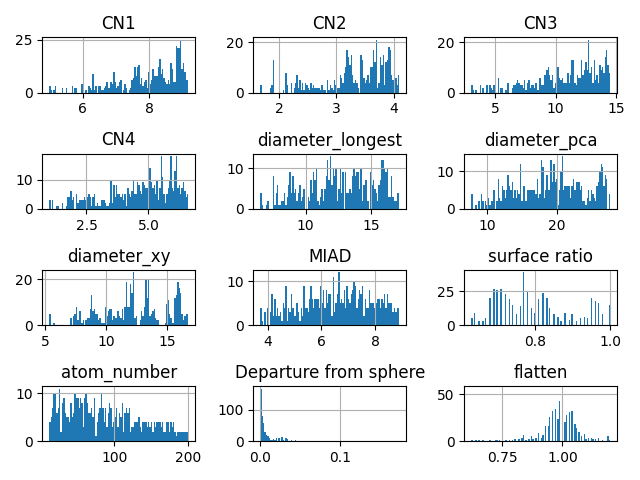

In [148]:
particles_descriptors=[]
bas=[]
for i in range(len(ini_atom_list)):
    particles_descriptors.append(descriptor_table(ini_atom_list[i]))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100)
plt.tight_layout()

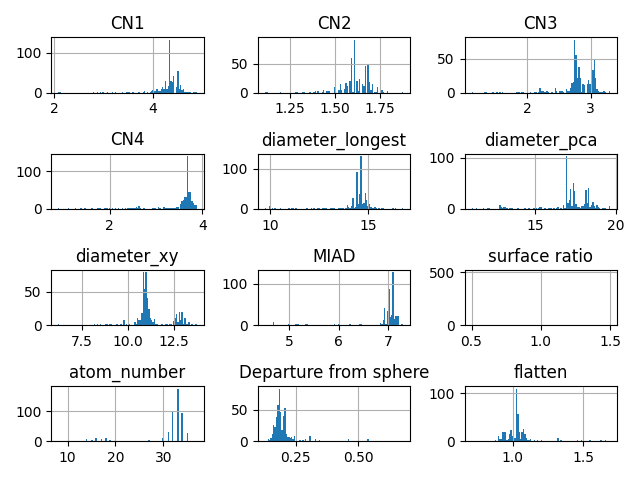

In [149]:
particles_descriptors=[]
bas=[]
for i in range(len(last_atom_list)):
    particles_descriptors.append(descriptor_table(last_atom_list[i]))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100)
plt.tight_layout()

In [24]:
pdes[pdes['flatten']<0.8]

,CN1,CN2,CN3,CN4,diameter_longest,diameter_pca,diameter_xy,MIAD,surface ratio,atom_number,Departure from sphere,flatten
195,2.79,1.54,2.08,2.38,14.16,19.24,13.29,7.41,1.0,24,0.137146,0.76
243,3.25,1.58,1.67,1.50,12.22,11.74,10.07,5.06,1.0,12,0.237598,0.62


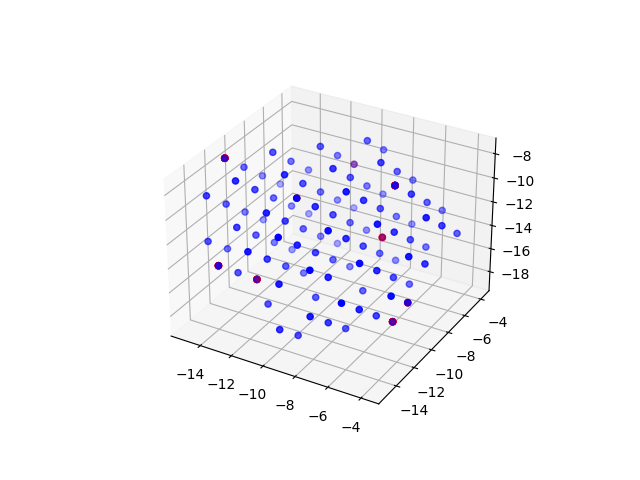

In [198]:
from scipy.spatial import ConvexHull
hull = ConvexHull(last_atom_list[323].positions)
conhull=[]
for sim in hull.simplices:
    conhull.append([last_atom_list[323].positions[sim[0],0],last_atom_list[323].positions[sim[0],1],last_atom_list[323].positions[sim[0],2]])
conhull=np.array(conhull)
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter(conhull[:,0],conhull[:,1],conhull[:,2],c='r')
ax.scatter(last_atom_list[323].positions[:,0],last_atom_list[323].positions[:,1],last_atom_list[323].positions[:,2],c='b')


In [106]:
def parents(population,fitness_values,tol=1e5):
    fitness_values=np.array(fitness_values)
    ranking=ranking_fitness(fitness_values)
    prob=normalized_p(ranking)
    # index=np.arange(len(population))
    # threshold=random.uniform(np.min(prob),np.max(prob))
    current=0
    index=0
    # for i in range(len(population)):
    while index<tol:
        # print(i)
        # print(f"prob={threshold},{prob[i]}")
        i=random.randint(0,len(population)-1)
        index+=1
        if random.uniform(0,1)<=prob[i]:
            # print("pass!")
            return population[i],ranking[i],prob[i]
        if index==tol:
            raise Exception("exceed the maximum try times!")
        
        
def ranking_fitness(fitness_values):
    fitness_ranking=np.zeros(len(fitness_values))
    fitness_dict=Counter(fitness_values)
    fitness_ordered=sorted(fitness_dict.keys(),reverse=False)
    rank=1
    for i in range(len(fitness_ordered)):
        indices=np.where(np.array(fitness_values)==fitness_ordered[i])[0]
        for j in indices:
            fitness_ranking[j]=rank
        rank+=1
    return fitness_ranking
def probability_selection(fitness_ranking):
    R=len(fitness_ranking)
    lamb=np.log(10)/(max(fitness_ranking)-min(fitness_ranking))
    # print(lamb)
    z=np.array([np.exp(-lamb*r) for r in fitness_ranking])
    z_sum=np.sum(z)
    return z/z_sum 
def normalized_p(fitness_ranking):
    p=probability_selection(fitness_ranking)
    return 0.8*(p-np.min(p))/(np.max(p)-np.min(p))+0.1

In [107]:
np.log(10)/999

0.0023048899829770228

(array([410., 306., 341., 264., 284., 255., 235., 239., 230., 204., 198.,
        218., 159., 163., 171., 194., 166., 162., 124., 112., 163., 131.,
        117., 125., 145.,  88., 114., 110., 106., 113., 139.,  91., 100.,
         69., 102.,  99., 106.,  63., 105.,  93.,  68.,  92.,  78.,  65.,
         97.,  65.,  62., 100.,  58.,  58.,  61.,  85.,  78.,  78.,  61.,
         57.,  62.,  81.,  70.,  78.,  43.,  79.,  71.,  67.,  38.,  64.,
         63.,  35.,  63.,  58.,  40.,  73.,  27.,  55.,  36.,  59.,  21.,
         80.,  29.,  62.,  36.,  63.,  26.,  33.,  66.,  30.,  33.,  74.,
         31.,  38.,  74.,  26.,  38.,  35.,  69.,  31.,  28.,  37.,  39.,
         62.]),
 array([0.1  , 0.108, 0.116, 0.124, 0.132, 0.14 , 0.148, 0.156, 0.164,
        0.172, 0.18 , 0.188, 0.196, 0.204, 0.212, 0.22 , 0.228, 0.236,
        0.244, 0.252, 0.26 , 0.268, 0.276, 0.284, 0.292, 0.3  , 0.308,
        0.316, 0.324, 0.332, 0.34 , 0.348, 0.356, 0.364, 0.372, 0.38 ,
        0.388, 0.396, 0.404, 0.412

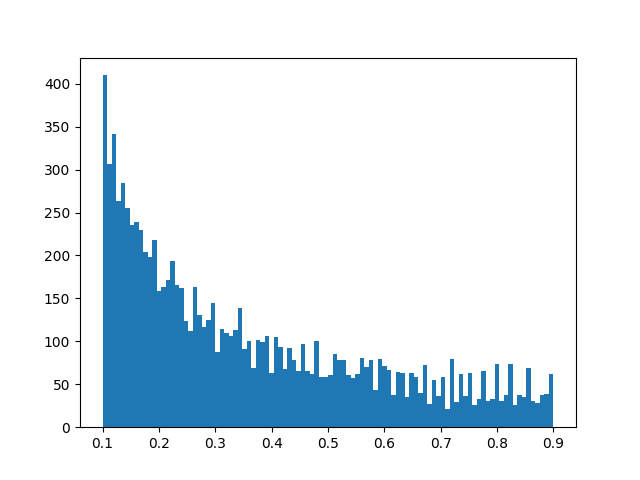

In [108]:
fitness=np.random.randint(0,300,10000)
prob=normalized_p(fitness)
plt.figure()
plt.hist(prob,bins=100)

[179. 619. 212.   6.  34.  14. 322. 276. 324. 328. 966. 140. 299. 931.
 965. 649. 643. 467. 105. 183.  45. 294. 815. 420. 395.  39. 105.  20.
 211. 282. 465. 488.  75. 274. 674. 122. 305. 528. 130. 115.  15. 123.
 183. 192. 672. 168.  46.  78. 107. 136.  68. 445. 269. 575. 946. 762.
 146. 786.  32. 999. 557. 234. 103.  55. 359. 123. 577. 139. 177. 351.
 320. 255. 319.  15. 415. 352. 236. 579.  74. 658. 140. 859. 547. 239.
 279.  66.   3. 523. 543. 235. 157. 707.  62. 384.  35. 505. 101. 435.
 176. 399. 426. 369. 517. 400.  48. 118. 673. 366. 337.  27. 364.  41.
 332. 737.  51. 205. 150. 993. 986. 115. 378. 599. 302. 573. 490. 428.
 514. 233. 273. 307.  66. 926. 829. 111. 228.  78. 351. 334. 161. 133.
 733. 231. 370. 371. 412.  95. 208. 302. 111. 606.   6. 860. 253. 184.
 894. 603. 104. 133.  33. 473. 177. 270. 370. 226. 543. 247. 105.  20.
 109. 161. 552.   1. 187. 927.  87. 135.  32. 264. 168. 245. 135. 204.
  92. 104. 223.  83. 921. 746.  87. 149.  62.  32. 426. 718. 722. 185.
 294. 

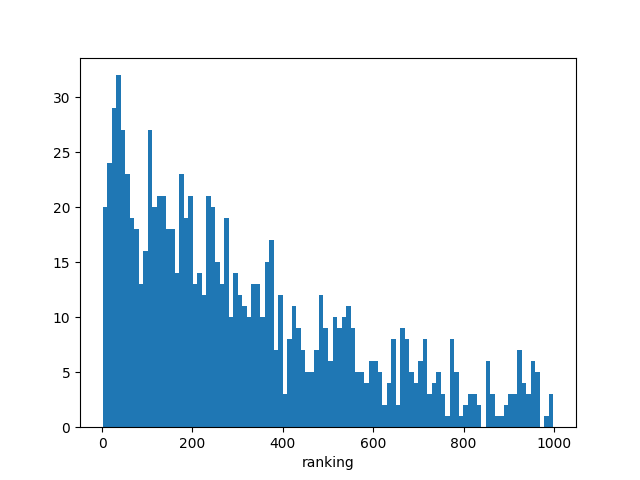

In [110]:
genome=np.random.uniform(0,1,1000)
fitness=np.random.uniform(0,500,1000)
ranking_distribution=[]

for i in range(1000):
    ranking_distribution.append(parents(genome,fitness)[1])
ranking=np.array(ranking_distribution)
plt.figure()
plt.hist(ranking,bins=100)
plt.xlabel('ranking')
print(ranking)
# parents(genome,fitness)

4
lattice has 365 points.
112


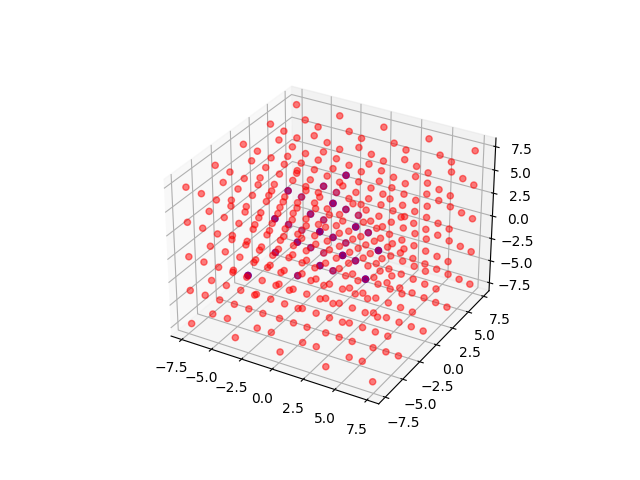

In [68]:
check=extendfcc(fccbasis(3.66),4,2,2,2)
num_atoms=100
generations=20
population_size=100
discriptors={"CN1":9.4,
                "CN2":4.0,
                "CN3":14.4,
                "CN4":7.1,
}
lc=3.67
lattice=empty_lattice(lc,num_atoms)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(lattice[:,0],lattice[:,1],lattice[:,2],c='r',alpha=0.5)
ax.scatter(best_atom.get_positions()[:,0],best_atom.get_positions()[:,1],best_atom.get_positions()[:,2],c='b')
# ax.scatter(lattice[ini_value==1][:,0],lattice[ini_value==1][:,1],lattice[ini_value==1][:,2],c='b')
print(len(check))

[2008.4404887108033, 2007.100607901656, 2018.2041625128347, 2008.2186237519522, 2009.071343638781, 2007.3470805956667, 2018.7075386195543, 2009.830362105026, 2007.3309967189691, 2007.9992690387207, 2007.951349868863, 2008.6781770473929, 2008.9283842614554, 2018.9972242559056, 2007.3149583657596, 2018.0700575253677, 2009.8166283369017, 2009.3503693299417, 2009.989167585465, 2008.3178240871894, 2007.1155823025551, 2009.736165439872, 2007.7538513997918, 2008.69373101291, 2018.1722425649657, 2018.5197171018767, 2007.0704150359002, 2017.6700897343994, 2008.2931149514811, 2008.1362884281123, 2007.7380550395685, 2008.6197698061842, 2009.6777174381054, 2008.338160291894, 2018.9721190135053, 2015.444572616012, 2009.317449000199, 2008.120567063157, 2018.4177631527905, 2009.9198369745427, 2007.796691222514, 2008.4689677483934, 2018.2794161583472, 2009.2672286078507, 2007.7737071899996, 2007.2215237475598, 2007.4829451616613, 2007.6675692580072, 2007.1033438126601, 2018.1147642916171, 2008.3135292

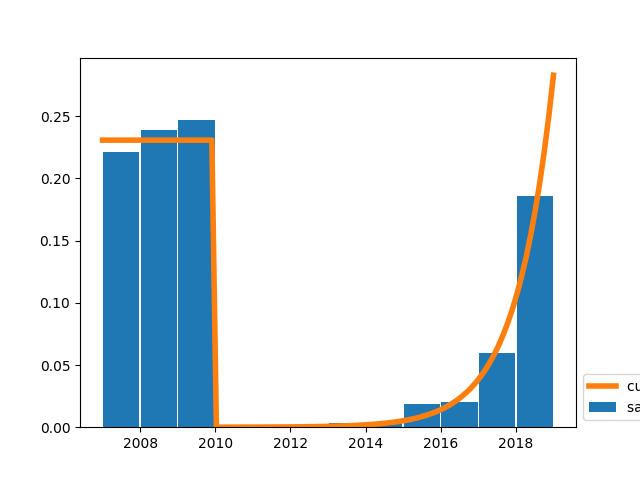

In [86]:
def random_custDist(x0,x1,custDist,size=None, nControl=10**6):
    #genearte a list of size random samples, obeying the distribution custDist
    #suggests random samples between x0 and x1 and accepts the suggestion with probability custDist(x)
    #custDist noes not need to be normalized. Add this condition to increase performance. 
    #Best performance for max_{x in [x0,x1]} custDist(x) = 1
    samples=[]
    nLoop=0
    while len(samples)<size and nLoop<nControl:
        x=np.random.uniform(low=x0,high=x1)
        prop=custDist(x)
        assert prop>=0 and prop<=1
        if np.random.uniform(low=0,high=1) <=prop:
            samples += [x]
        nLoop+=1
    return samples

#call
x0=2007
x1=2019
def custDist(x):
    if x<2010:
        return .3
    else:
        return (np.exp(x-2008)-1)/(np.exp(2019-2007)-1)
samples=random_custDist(x0,x1,custDist=custDist,size=1000)
print(samples)

#plot
import matplotlib.pyplot as plt
#hist
plt.figure()
bins=np.linspace(x0,x1,int(x1-x0+1))
hist=np.histogram(samples, bins )[0]
hist=hist/np.sum(hist)
plt.bar( (bins[:-1]+bins[1:])/2, hist, width=.96, label='sample distribution')
#dist
grid=np.linspace(x0,x1,100)
discCustDist=np.array([custDist(x) for x in grid]) #distrete version
discCustDist*=1/(grid[1]-grid[0])/np.sum(discCustDist)
plt.plot(grid,discCustDist,label='custom distribustion (custDist)', color='C1', linewidth=4)
#decoration
plt.legend(loc=3,bbox_to_anchor=(1,0))
plt.show()

NameError: name 'fitness_record' is not defined

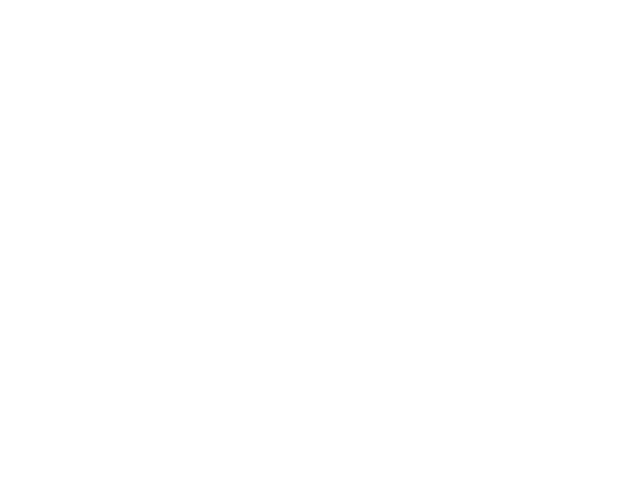

In [87]:
# plt.figure(np.array(fitness_record))
plt.figure()
plt.plot(fitness_record)
plt.xlabel('Generation')
plt.ylabel('Fitness')
np.array(fitness_record)


In [38]:
a=np.array([1,2,3,4])
b=np.array([2,3,4,5])
a[:2]+b[2:]

array([5, 7])

In [39]:
random.uniform(1,3)

1.5331254155161587

In [65]:
# fig = plt.figure()
positions=particles_encode_gen(3.67,num_atoms=None,max_num_atoms=200)

ax = fig.add_subplot(projection='3d')
# ax.scatter(best_atom.get_positions()[:,0],best_atom.get_positions()[:,1],best_atom.get_positions()[:,2],c='r',s=100)
#ba=Atoms(positions=best_atom.get_positions(),symbols=['Pt']*len(best_atom.get_positions()))
# ba=Atoms(positions=positions,symbols=['Pt']*len(positions))


In [4]:
lattice_big,mid_position=empty_lattice(3.67,4,4,4)
lattice=empty_lattice(3.67,1,4,4,mid_position)
# order_lattice=order_pos(lattice,mid_position=None)

index=[]
for i in range(100):
    index.extend(np.where(np.all(np.isclose(lattice_big,order_lattice[i],rtol=1e-5),axis=1))[0])
index
positions=lattice_big[index]


NameError: name 'extendfcc' is not defined

In [237]:
from shape_proj_util.geo_tools.geometry import *
import pandas as pd

In [147]:
populations,parameters=ini_population(1000,200,3.77,num_atoms=None)
particles_descriptors=[]
bas=[]
for i in range(len(populations)):
    decode,big_lattice=recon_coordfromcodes(populations[i],3.77,200)
    ba=Atoms(positions=decode,symbols=['Pt']*len(decode))
    bas.append(ba)
    particles_descriptors.append(descriptor_table(ba))
pdes=pd.DataFrame(particles_descriptors)






In [170]:
def atom_trancate_center(genome,theta,phi,lc,max_num_atoms):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    center=np.mean(particle,axis=0)
    normal=normal_vector(center,theta,phi)
    print(normal)
    print(f"center={center}")
    trancate_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=0:
            trancate_particle.append([pos[0],pos[1],pos[2]])
    if len(trancate_particle)<5:
        genome_recon=np.zeros(len(genome))
    else:
        genome_recon=encode_fromcoord(trancate_particle,big_lattice)
    return particle,normal,center,genome_recon
    
def atom_trancate_arbi(genome,theta,phi,x0,y0,z0,lc,max_num_atoms):
    center=[x0,y0,z0]
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    normal=normal_vector(center,theta,phi)
    trancate_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=0:
            trancate_particle.append([pos[0],pos[1],pos[2]])
    if len(trancate_particle)<5:
        trancate_particle=[]
        for pos in particle:
            if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])<=0:
                trancate_particle.append([pos[0],pos[1],pos[2]])
    genome_recon=encode_fromcoord(trancate_particle,big_lattice)
    return genome_recon
def recon_coordfromcodes(genome,lc,max_num_atoms):
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice_big,mid_position=empty_lattice(lc,n_max,n_max,n_max)
    index=list(np.where(np.array(genome)==1)[0])
    # print(index)
    return np.array(lattice_big[index]),lattice_big

def encode_fromcoord(particle,lattice):
    index=[]
    for i in range(len(particle)):
        index.extend(np.where(np.all(np.isclose(lattice,particle[i],rtol=1e-3),axis=1))[0])
    genome_recon=np.zeros(len(lattice))
    for i in index:
        genome_recon[i]=1
    return genome_recon

In [14]:
#test====
# position,normal,center,g=atom_trancate_center(populations[0],np.pi,np.pi/2,3.77,200)
# np.mean(b,axis=0)
# plane=[]
# for pos in position:
#     if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=0:
#         plane.append([pos[0],pos[1],pos[2]])
# plane=np.array(plane)
# len(plane)
# genome_recon=encode_fromcoord(plane,big_lattice)
# index=[]
# for i in range(len(plane)):
#     index.extend(np.where(np.all(np.isclose(big_lattice,plane[i],rtol=1e-3),axis=1))[0])
# index

# plane[1]

# test for 4th try

## 1. crossover function

In [159]:
max_num_atoms=200
generations=20
population_size=500
lc=3.77
mutation_rate=0.1
cross_over_rate=0.8
descriptors={"surface ratio": 1,
                "atom_number": 100#"CN1":9.1,
#                "CN2":4.3,
#                "CN3":11,
#                "CN4":8

}
num_lattice=max_num_atoms//2 #since one unit cell of fcc lattice has 2 atoms
n_max=int(np.ceil(np.cbrt(num_lattice)))
lattice_big,_=empty_lattice(lc,n_max,n_max,n_max)

#2. initialization of populations
populations,parameters = ini_population(lc=lc,
                            population_size=population_size,
                            max_num_atoms=max_num_atoms,
                            num_atoms=None)



In [160]:
fitness_values=[fitness(genome,lc,max_num_atoms,descriptors)[0] for genome in populations]

In [161]:
parent1,parameters1=parents(populations,parameters,fitness_values)
parent2,parameters2=parents(populations,parameters,fitness_values)
fit_parent1=fitness(parent1,lc,max_num_atoms,descriptors)[0]
fit_parent2=fitness(parent2,lc,max_num_atoms,descriptors)[0]

In [162]:
fit_parent1,fit_parent2

(1156.0529, 3025.0169)

In [163]:
offspring1,offspring2=crossover(lc,parent1,parent2,cross_over_rate=0.8,max_num_atoms=200)

In [156]:
# offspring1
# n_count=0

# children1,children2=crossover(lc,parent1,parent2,cross_over_rate=cross_over_rate,max_num_atoms=max_num_atoms)
# fit_children1=fitness(parent1,lc,max_num_atoms,descriptors)[0]
# fit_children2=fitness(parent2,lc,max_num_atoms,descriptors)[0]
# while max(fit_children1,fit_children2)>=np.mean([fit_parent1,fit_parent2]) and n_count<100:
#     children1,children2=crossover(lc,parent1,parent2,cross_over_rate=cross_over_rate,max_num_atoms=max_num_atoms)
#     fit_children1=fitness(parent1,lc,max_num_atoms,descriptors)[0]
#     fit_children2=fitness(parent2,lc,max_num_atoms,descriptors)[0]
#     n_count+=1
# fit_children1,fit_children2,n_count

In [145]:
new_populations = []
populations_add=populations
#check duplicates, if duplicates exist, then generate a new structure
for _ in range(population_size//2):
    #[1]. find parents from populations based on fitness values
    # print(len(populations),len(parameters),len(fitness_values))
    parent1,parameters1=parents(populations_add,parameters,fitness_values)
    parent2,parameters2=parents(populations_add,parameters,fitness_values)
    fit_parent1=fitness(parent1,lc,max_num_atoms,descriptors)
    fit_parent2=fitness(parent2,lc,max_num_atoms,descriptors)
    #[2]. crossover and mutation to generate offsprings
    children1,children2=crossover(lc,parent1,parent2,cross_over_rate=cross_over_rate,max_num_atoms=max_num_atoms)
    # print(f"children={len(np.where(np.array(children1)==1)[0]),len(np.where(np.array(children2)==1)[0])}")
    children1=mutation(children1,lc,max_num_atoms,mutation_rate=mutation_rate)
    children2=mutation(children2,lc,max_num_atoms,mutation_rate=mutation_rate)
    new_populations.extend([children1,children2])
    populations_add=new_populations

In [143]:
fitness_values_new=[fitness(genome,lc,max_num_atoms,descriptors)[0] for genome in new_populations]

In [146]:
fitness_values_new2=[fitness(genome,lc,max_num_atoms,descriptors)[0] for genome in new_populations]

(array([56., 25., 22., 17., 19., 13., 10.,  9.,  9.,  8., 12.,  4., 10.,
         4.,  7., 11.,  9.,  4.,  5.,  5.,  3.,  3.,  5.,  5.,  8.,  1.,
         3.,  6.,  5.,  4.,  7.,  6.,  7.,  5.,  5.,  7.,  0.,  8.,  5.,
         8.,  3.,  0.,  6.,  6.,  5.,  0.,  4.,  3.,  7.,  0.,  7.,  5.,
         0.,  8.,  4.,  0.,  4.,  3.,  0.,  5.,  6.,  0.,  5.,  4.,  0.,
         8.,  0.,  6.,  5.,  0.,  5.,  0.,  7.,  4.,  0.,  4.,  0.,  4.,
         0.,  1.,  0.,  1.,  1.,  0.,  1.,  0.,  1.,  0.,  1.,  0.,  1.,
         0.,  1.,  0.,  1.,  0.,  1.,  0.,  1.,  1.]),
 array([6.76000000e-02, 1.00068293e+02, 2.00068986e+02, 3.00069679e+02,
        4.00070372e+02, 5.00071065e+02, 6.00071758e+02, 7.00072451e+02,
        8.00073144e+02, 9.00073837e+02, 1.00007453e+03, 1.10007522e+03,
        1.20007592e+03, 1.30007661e+03, 1.40007730e+03, 1.50007800e+03,
        1.60007869e+03, 1.70007938e+03, 1.80008007e+03, 1.90008077e+03,
        2.00008146e+03, 2.10008215e+03, 2.20008285e+03, 2.30008354e+03,
  

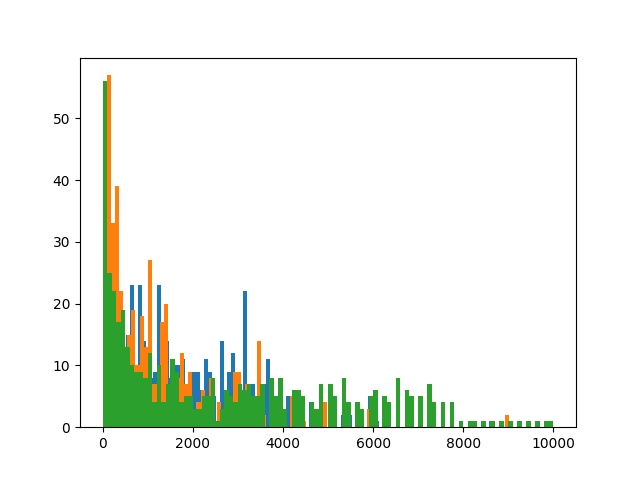

In [157]:
plt.figure()
plt.hist(fitness_values_new2,bins=100)
plt.hist(fitness_values_new,bins=100)
plt.hist(fitness_values,bins=100)

# 2. optimize nanoparticle maximize coordination number

In [112]:
view(last_atom_list[50],viewer='x3d')

In [102]:
positions=last_atom_list[50].positions
CNs=[]
dis=[]
for i in range(len(positions)):
    CNs.append(getCN_dis_Oneshell(positions,positions[i],1,thickness=0.1)[0])
    dis.append(getCN_dis_Oneshell(positions,positions[i],1,thickness=0.1)[1])

In [61]:
dis

[[2.6658],
 [2.6658],
 [2.6658],
 [2.6658],
 [2.6658],
 [2.6658],
 [2.6658],
 [2.6658],
 [2.6658],
 [2.6658],
 [2.6658],
 [2.6658],
 [2.6658],
 [2.6658],
 [2.6658],
 [2.6658],
 [2.6658],
 [2.6658],
 [2.6658],
 [2.6658],
 [2.6658],
 [2.6658],
 [2.6658],
 [2.6658],
 [2.6658],
 [5.9609],
 [2.6658],
 [2.6658],
 [2.6658]]

In [39]:
encodes=encode_fromcoord(positions,3.77,200)
particle,big_lattice=recon_coordfromcodes(encodes,3.77,200)
np.where(encodes==1)[0]

array([  1,   5,   6,   7,  10,  11,  14,  15,  17,  23,  24,  25,  34,
        41,  42,  68,  69,  74,  82,  92, 127, 139, 150, 200, 201, 206,
       214, 276, 332], dtype=int64)

In [209]:
# new_particle=[]

particle_get=last_atom_list[0].positions
atom_num=len(particle_get)
CN_steps=[]
index_particle=[]
zero_dict=dict()
encodes=encode_fromcoord(particle_get,3.77,200)
control=0
while control<100:
    CNs1=[]
    dis1=[]
    index_particle=[]
    particle,big_lattice=recon_coordfromcodes(encodes,3.77,200)
    for i in  range(len(big_lattice)):
        if encodes[i]==1:
            CN1,dis=getCN_dis_Oneshell(particle,big_lattice[i],1,thickness=0.1)
            if  dis<=np.round(np.sqrt(2)/2*3.77,4) and CN1>10: 
                index_particle.append(i)
            else:
                encodes[i]=0
    
    for i in range(len(big_lattice)):     
        if encodes[i]==0:
            CN0,dis=getCN_dis_Oneshell(particle,big_lattice[i],1,thickness=0.1)
            if  CN0!=0 and dis<=np.round(np.sqrt(2)/2*3.77,4):
                zero_dict[i]=CN0
    zero_dict=dict(sorted(zero_dict.items(), key=lambda item: item[1],reverse=True))
    residual=atom_num-len(index_particle)
    for i in range(residual):
        encodes[list(zero_dict.keys())[i]]=1
    # print(f"particle {j}")
    particle,big_lattice=recon_coordfromcodes(encodes,3.77,200)
    atom=Atoms(positions=particle,symbols=['Pt']*len(particle))
    _,_,CN_ave=getCN_dis_N(atom,1)
    control+=1
    CN_steps.append(CN_ave)
    if control>20:
        if CN_steps[-1]-CN_steps[-2]<1e-3:
            break
    
# CNs1=np.array(CNs1)
# CNs0=np.array(CNs0)

In [210]:
CN_steps

[5.575757575757576,
 6.25,
 6.451612903225806,
 6.466666666666667,
 6.580645161290323,
 6.6,
 6.6,
 6.6,
 6.6,
 6.6,
 6.6,
 6.6,
 6.6,
 6.6,
 6.6,
 6.6,
 6.6,
 6.6,
 6.6,
 6.6,
 6.6]

In [172]:
particle=last_atom_list[0].positions
encodes=encode_fromcoord(positions,3.77,200)
a=convex_particle(encodes,1,3.77,200)


In [187]:
x=Atoms(positions=particle_get,symbols=['Pt']*len(particle))
view(x,viewer='x3d')

In [211]:
# a=Atoms(positions=particle_new,symbols=['Pt']*len(particle))
view(atom,viewer='x3d')

In [127]:
particle=last_atom_list[50]
particle

Atoms(symbols='Pt29', pbc=False)

In [184]:
# new_particle=[]

particle_get=last_atom_list[0].positions
atom_num=len(particle_get)
CN_steps=[]
index_particle=[]
zero_dict=dict()
encodes=encode_fromcoord(particle_get,3.77,200)
control=0
while control<100:
    CNs1=[]
    dis1=[]
    index_particle=[]
    particle,big_lattice=recon_coordfromcodes(encodes,3.77,200)
    for i in  range(len(big_lattice)):
        if encodes[i]==1:
            CN1,dis=getCN_dis_Oneshell(particle,big_lattice[i],1,thickness=0.1)
            if  dis<=np.round(np.sqrt(2)/2*3.77,4) and CN1>10: 
                index_particle.append(i)
            else:
                encodes[i]=0
    
    for i in range(len(big_lattice)):     
        if encodes[i]==0:
            CN0,dis=getCN_dis_Oneshell(particle,big_lattice[i],1,thickness=0.1)
            if  CN0!=0 and dis<=np.round(np.sqrt(2)/2*3.77,4):
                zero_dict[i]=CN0
    zero_dict=dict(sorted(zero_dict.items(), key=lambda item: item[1],reverse=True))
    residual=atom_num-len(index_particle)
    for i in range(residual):
        encodes[list(zero_dict.keys())[i]]=1
    # print(f"particle {j}")
    particle,big_lattice=recon_coordfromcodes(encodes,3.77,200)
    atom=Atoms(positions=particle,symbols=['Pt']*len(particle))
    _,_,CN_ave=getCN_dis_N(atom,1)
    control+=1
    CN_steps.append(CN_ave)
    if control>20:
        if CN_steps[-1]-CN_steps[-2]<1e-3:
            break

        
